In [ ]:
import os
print(os.getcwd())

C:\Users\ypd00


In [ ]:
# 2. 수강생용 Python 코드
# 2-1. 데이터 불러오기 및 기본 확인
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기 (TB_MEMBER.csv, TB_SALES.csv)
member_df = pd.read_csv('TB_MEMBER.csv')
sales_df = pd.read_csv('TB_SALES.csv')

# 데이터 크기 및 일부 확인
print("고객 수:", len(member_df), "/ 거래 수:", len(sales_df))
print(member_df.head(5))      # 회원 데이터 샘플
print(sales_df.head(5))       # 거래 데이터 샘플


고객 수: 1000 / 거래 수: 98889
   CustID  Age Gender   Region CardHolder  NumCards  CreditScore  SignUp
0       1   56      F  Daejeon          Y         1   653.542443       1
1       2   69      F    Busan          Y         4   687.782277       0
2       3   46      M    Seoul          N         0   512.120492       0
3       4   32      M    Other          N         0   563.897020       0
4       5   60      M    Busan          Y         3   591.352955       1
   CustID        Date Category  Amount
0       1  2024-08-15       마트  229.18
1       1  2024-01-22       마트  260.44
2       1  2024-06-27       식당   60.57
3       1  2024-01-28       식당  186.85
4       1  2024-11-13      OTT   11.95


In [ ]:
# 컬럼 정보 및 결측치 개수 확인
print(member_df.isnull().sum())   # 각 컬럼별 결측치 개수
print(sales_df.isnull().sum())    # (TB_SALES는 결측치 없을 것으로 예상)

CustID          0
Age             0
Gender          0
Region          0
CardHolder      0
NumCards        0
CreditScore    20
SignUp          0
dtype: int64
CustID      0
Date        0
Category    0
Amount      0
dtype: int64


In [ ]:
# 결측치 처리: CreditScore 컬럼의 결측값을 중앙값(median)으로 대체
# median(): CreditScore 컬럼의 중앙값 계산
median_score = member_df['CreditScore'].median()

# fillna(): 결측값(NaN)을 지정한 값으로 대체
# inplace=True → 원본 DataFrame(member_df)에 바로 반영
member_df['CreditScore'].fillna(median_score, inplace=True)

# isnull(): 결측 여부(True/False) 반환
# sum(): True를 1로 계산하여 결측값 개수 집계
# → 결측치 처리 후 CreditScore 컬럼의 결측값 개수 확인
print(
    "Number of missing values in CreditScore after imputation:",
    member_df['CreditScore'].isnull().sum()
)

Number of missing values in CreditScore after imputation: 0


In [ ]:
# 기초 통계량으로 데이터 분포 확인
# describe(): 수치형 변수의 개수(count), 평균(mean), 표준편차(std),
#              최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max) 출력
# → Age, NumCards, CreditScore, SignUp 변수의 전반적인 분포와 이상치 여부 파악

print(member_df[['Age', 'NumCards', 'CreditScore', 'SignUp']].describe())

               Age     NumCards  CreditScore       SignUp
count  1000.000000  1000.000000  1000.000000  1000.000000
mean     50.380000     2.388000   617.204436     0.351000
std      18.378666     1.747143   134.922222     0.477522
min      18.000000     0.000000   300.000000     0.000000
25%      35.000000     1.000000   520.824410     0.000000
50%      50.000000     2.000000   615.163374     0.000000
75%      66.000000     4.000000   715.477959     1.000000
max      80.000000     5.000000   900.000000     1.000000


In [ ]:
# 범주형 변수 분포 확인
# value_counts(): 각 범주(category)별 데이터 개수를 집계
# → 성별(Gender), 지역(Region), 신용카드 보유여부(CardHolder)의 분포 파악

print("Gender Distribution:\n", member_df['Gender'].value_counts())
print("Region Distribution:\n", member_df['Region'].value_counts())
print("CardHolder Distribution:\n", member_df['CardHolder'].value_counts())

Gender Distribution:
 F    523
M    477
Name: Gender, dtype: int64
Region Distribution:
 Other      214
Busan      212
Gwangju    208
Seoul      192
Daejeon    174
Name: Region, dtype: int64
CardHolder Distribution:
 Y    800
N    200
Name: CardHolder, dtype: int64


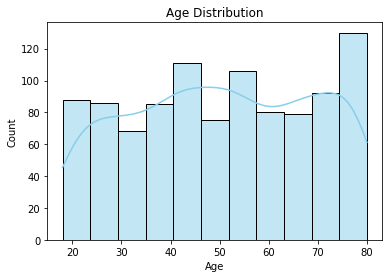

In [ ]:
# 연령(Age) 분포 시각화
# figure(): 그래프 크기 설정
plt.figure(figsize=(6, 4))

# histplot(): 히스토그램으로 분포 시각화
# kde=True → 커널 밀도 곡선(KDE) 함께 표시
# → 연령 데이터의 분포 형태를 부드럽게 확인 가능
sns.histplot(member_df['Age'], kde=True, color='skyblue')

# title(): 그래프 제목 설정
plt.title('Age Distribution')  # 연령 분포

# show(): 그래프 출력
plt.show()


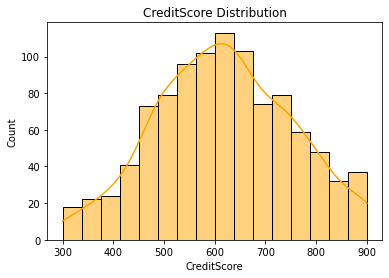

In [ ]:
# 신용점수(CreditScore) 분포 시각화
# figure(): 그래프 크기 설정
plt.figure(figsize=(6, 4))

# histplot(): 히스토그램으로 분포 시각화
# kde=True → 커널 밀도 곡선(KDE) 함께 표시
# → 신용점수 데이터의 분포 형태 및 치우침 여부 확인
sns.histplot(member_df['CreditScore'], kde=True, color='orange')

# title(): 그래프 제목 설정
plt.title('CreditScore Distribution')  # 신용점수 분포

# show(): 그래프 출력
plt.show()

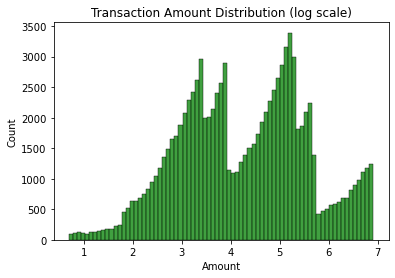

In [ ]:
# 거래 금액(Amount) 분포 시각화
# log1p(): log(1 + x) 변환 → 0 값이 있어도 안전하게 로그 변환 가능
# → 오른쪽 꼬리가 긴 분포(우측 치우침)를 완화하여 분포 형태 확인

# figure(): 그래프 크기 설정
plt.figure(figsize=(6, 4))

# histplot(): 히스토그램으로 분포 시각화
sns.histplot(np.log1p(sales_df['Amount']), color='green')

# title(): 그래프 제목 설정
plt.title('Transaction Amount Distribution (log scale)')
# 거래 금액 분포 (log 스케일)

# show(): 그래프 출력
plt.show()

In [ ]:
# 고객별 거래 건수 분포 확인
# groupby('CustID'): 고객 ID 기준으로 데이터 그룹화
# size(): 각 고객별 거래 건수 계산
trans_per_cust = sales_df.groupby('CustID').size()

# describe(): 고객별 거래 건수의 개수(count), 평균(mean), 표준편차(std),
#             최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max) 출력
# → 고객별 거래 빈도 분포 및 과다/저빈도 고객 여부 파악
print(trans_per_cust.describe())


count    1000.000000
mean       98.889000
std        46.948278
min        20.000000
25%        57.000000
50%        98.500000
75%       139.250000
max       179.000000
dtype: float64


In [ ]:
# 목표 변수(SignUp) 분포 확인
# mean(): 이진 변수(0/1)의 평균 → 1의 비율 = 전체 가입률(Sign-Up Rate)
signup_rate = member_df['SignUp'].mean()

# f-string: 계산된 값을 문자열에 바로 삽입하여 가독성 있게 출력
# :.3f → 소수점 3자리까지 표시
# :.1f → 소수점 1자리까지 퍼센트(%)로 표시
print(
    f"Overall Sign-Up Rate: {signup_rate:.3f} "
    f"(Sign-Up percentage {signup_rate*100:.1f}%)"
)


Overall Sign-Up Rate: 0.351 (Sign-Up percentage 35.1%)


In [ ]:
# 고객 단위 집계 변수 생성 (TB_CUST_AGG)
# groupby('CustID'): 고객 ID 기준으로 거래 데이터 그룹화
# agg(): 여러 집계 함수를 한 번에 적용
#  - TotalTrans : 거래 금액(Amount)의 개수 → 고객별 총 거래 건수
#  - TotalAmount: 거래 금액(Amount)의 합계 → 고객별 총 거래 금액
cust_sales_agg = sales_df.groupby('CustID').agg(
    TotalTrans=('Amount', 'count'),
    TotalAmount=('Amount', 'sum')
)

# 고객별 거래 집계 결과 확인
print(cust_sales_agg)


        TotalTrans  TotalAmount
CustID                         
1              123     15013.43
2               34      5084.65
3              123     12221.57
4              161     27546.52
5              179     29830.84
...            ...          ...
996            113     14218.73
997            162     25781.03
998            167     24775.16
999             97     11368.80
1000            83     13132.95

[1000 rows x 2 columns]


In [ ]:
# 고객별 업종(Category)별 매출 합계 피벗 테이블 생성
# pivot_table():
#  - index='CustID'  → 고객 단위로 행 생성
#  - columns='Category' → 업종을 컬럼으로 변환
#  - values='Amount' → 집계 대상 금액
#  - aggfunc='sum' → 업종별 거래 금액 합계
#  - fill_value=0 → 거래가 없는 업종은 0으로 채움
category_sums = sales_df.pivot_table(
    index='CustID',
    columns='Category',
    values='Amount',
    aggfunc='sum',
    fill_value=0
)

# 컬럼명을 영문 변수명으로 변경 (모델링/분석용)
category_sums = category_sums.rename(columns={
    '편의점': 'ConvStore_Amt',
    '마트': 'Mart_Amt',
    'OTT': 'OTT_Amt',
    '식당': 'Dining_Amt',
    '여행': 'Travel_Amt'
})

# 고객별 업종 매출 합계 결과 확인
print(category_sums)


Category  OTT_Amt  Mart_Amt  Dining_Amt  Travel_Amt  ConvStore_Amt
CustID                                                            
1          778.08   3742.81     3164.61     6985.84         342.09
2            7.50   1452.24     1426.01     1967.71         231.19
3          604.40   3840.48     2453.83     4789.23         533.63
4          207.61   7574.41     3516.92    15168.33        1079.25
5          349.63   6633.27     4438.84    17228.24        1180.86
...           ...       ...         ...         ...            ...
996        283.87   3785.65     2972.27     6546.31         630.63
997         23.85   5646.32     5341.20    13404.96        1364.70
998        679.47   5184.17     4257.73    13817.32         836.47
999        365.90   2857.48     1612.83     5891.44         641.15
1000         0.00   3145.13     2456.83     7007.39         523.60

[1000 rows x 5 columns]


In [ ]:
# 고객 단위 집계 테이블 결합
# merge(): 여러 집계 테이블을 하나의 DataFrame으로 결합
# left_index=True, right_index=True → CustID 인덱스를 기준으로 병합
cust_agg = pd.merge(
    cust_sales_agg,
    category_sums,
    left_index=True,
    right_index=True
)

# reset_index(): 인덱스였던 CustID를 일반 컬럼으로 변환
cust_agg = cust_agg.reset_index()

# 최종 고객 단위 집계 테이블 확인
print(cust_agg)


     CustID  TotalTrans  TotalAmount  OTT_Amt  Mart_Amt  Dining_Amt  \
0         1         123     15013.43   778.08   3742.81     3164.61   
1         2          34      5084.65     7.50   1452.24     1426.01   
2         3         123     12221.57   604.40   3840.48     2453.83   
3         4         161     27546.52   207.61   7574.41     3516.92   
4         5         179     29830.84   349.63   6633.27     4438.84   
..      ...         ...          ...      ...       ...         ...   
995     996         113     14218.73   283.87   3785.65     2972.27   
996     997         162     25781.03    23.85   5646.32     5341.20   
997     998         167     24775.16   679.47   5184.17     4257.73   
998     999          97     11368.80   365.90   2857.48     1612.83   
999    1000          83     13132.95     0.00   3145.13     2456.83   

     Travel_Amt  ConvStore_Amt  
0       6985.84         342.09  
1       1967.71         231.19  
2       4789.23         533.63  
3      15168.33

In [ ]:
# 회원 정보(member_df)와 고객 단위 집계 데이터(cust_agg) 통합
# merge(): CustID를 기준으로 두 DataFrame을 하나로 결합
# → 한 행(row)이 한 명의 고객을 의미하는 최종 분석 테이블 생성
cust_agg_df = pd.merge(member_df, cust_agg, on='CustID')

# head(5): 통합된 데이터 상위 5행 출력
# → 고객별 모든 변수(회원 정보 + 거래/업종 집계 변수) 구조 확인
print(cust_agg_df.head(5))

# columns.tolist(): 컬럼명을 리스트 형태로 출력
# → 최종 분석 데이터셋에 포함된 전체 변수 목록 확인
print("통합 데이터 셋 컬럼:", cust_agg_df.columns.tolist())


   CustID  Age Gender   Region CardHolder  NumCards  CreditScore  SignUp  \
0       1   56      F  Daejeon          Y         1   653.542443       1   
1       2   69      F    Busan          Y         4   687.782277       0   
2       3   46      M    Seoul          N         0   512.120492       0   
3       4   32      M    Other          N         0   563.897020       0   
4       5   60      M    Busan          Y         3   591.352955       1   

   TotalTrans  TotalAmount  OTT_Amt  Mart_Amt  Dining_Amt  Travel_Amt  \
0         123     15013.43   778.08   3742.81     3164.61     6985.84   
1          34      5084.65     7.50   1452.24     1426.01     1967.71   
2         123     12221.57   604.40   3840.48     2453.83     4789.23   
3         161     27546.52   207.61   7574.41     3516.92    15168.33   
4         179     29830.84   349.63   6633.27     4438.84    17228.24   

   ConvStore_Amt  
0         342.09  
1         231.19  
2         533.63  
3        1079.25  
4        

In [ ]:
# 가입여부(SignUp) 그룹별 비교 분석
# groupby('SignUp'): 가입 여부(0/1)를 기준으로 고객 그룹 분리
# mean(): 각 그룹별 주요 변수의 평균 계산
# → 가입자 vs 비가입자의 특성 차이 비교
group_means = cust_agg_df.groupby('SignUp')[
    ['Age', 'CreditScore', 'TotalTrans', 'TotalAmount', 'OTT_Amt']
].mean()

# 가입여부 그룹별 평균 결과 출력
print("Average by Sign-Up Group:\n", group_means)

Average by Sign-Up Group:
               Age  CreditScore  TotalTrans   TotalAmount     OTT_Amt
SignUp                                                              
0       47.804314   612.516702   99.523883  15527.834900  150.323097
1       55.142450   625.872069   97.715100  13745.488405  310.194217


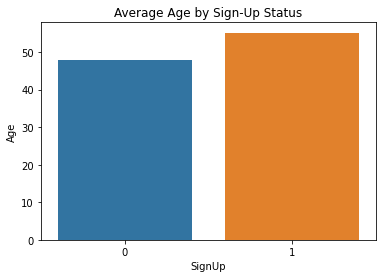

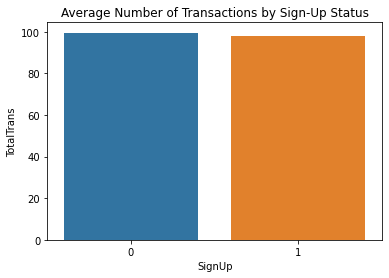

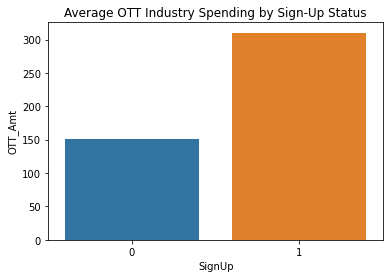

In [ ]:
# 시각화: 가입여부(SignUp)에 따른 주요 변수 평균 비교
# barplot(): 범주형 변수별 평균값을 막대그래프로 시각화
# estimator=np.mean → 평균값 기준
# ci=None → 신뢰구간 표시 제거 (평균 비교에 집중)

# 가입여부에 따른 평균 연령 비교
plt.figure(figsize=(6, 4))
sns.barplot(x='SignUp', y='Age', data=cust_agg_df, estimator=np.mean, ci=None)
plt.title('Average Age by Sign-Up Status')
plt.show()

# 가입여부에 따른 평균 거래 건수 비교
plt.figure(figsize=(6, 4))
sns.barplot(x='SignUp', y='TotalTrans', data=cust_agg_df, estimator=np.mean, ci=None)
plt.title('Average Number of Transactions by Sign-Up Status')
plt.show()

# 가입여부에 따른 OTT 업종 평균 지출 금액 비교
plt.figure(figsize=(6, 4))
sns.barplot(x='SignUp', y='OTT_Amt', data=cust_agg_df, estimator=np.mean, ci=None)
plt.title('Average OTT Industry Spending by Sign-Up Status')
plt.show()


In [ ]:
# 범주형 변수에 따른 가입률 비교
# groupby(): 범주형 변수 기준으로 고객 그룹화
# mean(): 이진 변수(SignUp)의 평균 → 해당 그룹의 가입률

# 성별(Gender)에 따른 가입률 계산
gender_signup_rate = cust_agg_df.groupby('Gender')['SignUp'].mean()

# 카드 보유 여부(CardHolder)에 따른 가입률 계산
cardholder_signup_rate = cust_agg_df.groupby('CardHolder')['SignUp'].mean()

# ott 여부(OTT_Amt)에 따른 가입률 계산
ott_signup_rate = cust_agg_df.groupby('OTT_Amt')['SignUp'].mean()

# 결과 출력
print("Sign-Up Rate by Gender:\n", gender_signup_rate)   # 성별에 따른 가입률
print("Sign-Up Rate by Card Ownership:\n", cardholder_signup_rate)  # 카드 보유 여부에 따른 가입률
print("ott_signup_rate:\n", ott_signup_rate)  # OTT 여부에 따른 가입률



Sign-Up Rate by Gender:
 Gender
F    0.376673
M    0.322851
Name: SignUp, dtype: float64
Sign-Up Rate by Card Ownership:
 CardHolder
N    0.24000
Y    0.37875
Name: SignUp, dtype: float64
ott_signup_rate:
 OTT_Amt
0.00       0.135714
5.04       0.000000
5.30       0.000000
5.40       0.000000
5.49       0.000000
             ...   
1214.94    1.000000
1222.16    1.000000
1266.68    1.000000
1307.76    1.000000
1310.19    1.000000
Name: SignUp, Length: 851, dtype: float64


In [ ]:
# ---------------------------------------------------------
# 📌 Statsmodels를 사용한 로지스틱 회귀 분석 (해석 중심)
# - summary()를 통해 계수(coef), p-value, 신뢰구간 확인 가능
# - "어떤 변수가 가입(SignUp)에 유의미한 영향을 주는지" 설명에 적합
# ---------------------------------------------------------

import statsmodels.formula.api as smf

# C(): 범주형 변수(Categorical) 지정
# → 모델 내부에서 자동으로 더미변수(dummy variable)로 변환
# formula 형식: 종속변수(SignUp) ~ 독립변수들
# ---------------------------------------------------------
# 📌 Statsmodels를 사용한 로지스틱 회귀 분석 (해석 중심)
# - summary()를 통해 계수(coef), p-value, 신뢰구간 확인 가능
# - "어떤 변수가 가입(SignUp)에 유의미한 영향을 주는지" 설명에 적합
# ---------------------------------------------------------

import statsmodels.formula.api as smf

# C(): 범주형 변수(Categorical) 지정
# → 모델 내부에서 자동으로 더미변수(dummy variable)로 변환
# formula 형식: 종속변수(SignUp) ~ 독립변수들
formula = (
    'SignUp ~ Age + C(Gender) + C(Region) + C(CardHolder) '
    '+ NumCards + CreditScore + TotalTrans '
    '+ OTT_Amt + Mart_Amt + Dining_Amt + Travel_Amt + ConvStore_Amt'
)

# logit(): 로지스틱 회귀 모델 생성
# fit(): 모델 학습(추정)
logit_model = smf.logit(formula, data=cust_agg_df).fit()

# summary(): 회귀 결과 요약 출력
# - coef : 회귀 계수(β)
# - P>|z| : p-value (통계적 유의성 판단)
# - [0.025, 0.975] : 95% 신뢰구간
print("\n📍 Statsmodels Logistic Regression Summary")
print(logit_model.summary())

# params: 추정된 회귀 계수(β값)만 출력
# → np.exp(params)를 적용하면 Odds Ratio(승산비)로 해석 가능
print("\n📍 회귀 계수 (Coefficients)")
print(logit_model.params)



Optimization terminated successfully.
         Current function value: 0.531650
         Iterations 6

📍 Statsmodels Logistic Regression Summary
                           Logit Regression Results                           
Dep. Variable:                 SignUp   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      984
Method:                           MLE   Df Model:                           15
Date:                Sun, 04 Jan 2026   Pseudo R-squ.:                  0.1796
Time:                        00:42:23   Log-Likelihood:                -531.65
converged:                       True   LL-Null:                       -648.06
Covariance Type:            nonrobust   LLR p-value:                 4.205e-41
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -3.0179      0.507   

In [ ]:
# ---------------------------------------------------------
# 📌 2) Scikit-learn을 사용한 로지스틱 회귀 (예측 성능 중심)
# - sklearn은 모델의 예측력(accuracy, confusion matrix, precision 등)을
#   평가하는 데 적합함.
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [ ]:
# ---------------------------------------------------------
# 2-5-1. 범주형 변수 더미화 처리
# ---------------------------------------------------------
# drop_first=True : 다중공선성 예방을 위해 기준 그룹(reference category) 제거
model_df = pd.get_dummies(
    cust_agg_df.drop(columns=['CustID']),
    columns=['Gender','Region','CardHolder'],
    drop_first=True
)

# X: 독립변수 / y: 종속변수
X = model_df.drop('SignUp', axis=1)
y = model_df['SignUp']


# ---------------------------------------------------------
# 2-5-2. 학습용 데이터(train) / 테스트 데이터(test) 분리 (8:2 비율)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


# ---------------------------------------------------------
# 2-5-3. 모델 학습 (Pipeline 방식 적용)
# StandardScaler → 변수의 단위 차이를 줄여 계산 안정화
# LogisticRegression → max_iter 증가(3000)하여 수렴 문제 해결
# ---------------------------------------------------------
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=3000))
])

clf.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('log_reg', LogisticRegression(max_iter=3000))])

In [ ]:
# ---------------------------------------------------------
# 2-5-4. 모델 성능 평가
# ---------------------------------------------------------
y_pred = clf.predict(X_test)

print("\n------------------------------------------")
print("📍 Scikit-learn Model Evaluation Results")
print("------------------------------------------")
print(f"Accuracy(정확도): {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix (혼동행렬):")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report (정밀도/재현율/F1):")
print(classification_report(y_test, y_pred))


------------------------------------------
📍 Scikit-learn Model Evaluation Results
------------------------------------------
Accuracy(정확도): 0.7250

Confusion Matrix (혼동행렬):
[[105  11]
 [ 44  40]]

Classification Report (정밀도/재현율/F1):
              precision    recall  f1-score   support

           0       0.70      0.91      0.79       116
           1       0.78      0.48      0.59        84

    accuracy                           0.73       200
   macro avg       0.74      0.69      0.69       200
weighted avg       0.74      0.72      0.71       200



In [ ]:
# ---------------------------------------------------------
# (선택) 예측확률 확인 → 마케팅 적용 시 타겟팅 기준으로 추천
# 예: 확률 0.6 이상이면 캠페인 발송
# ---------------------------------------------------------

y_proba = clf.predict_proba(X_test)[:, 1]
print("\n📍 예측 확률 샘플 (상위 10개)")
print(y_proba[:10])


📍 예측 확률 샘플 (상위 10개)
[0.49593515 0.05573525 0.40323657 0.60332612 0.67980492 0.11774291
 0.1326504  0.22805263 0.39164251 0.16629314]


In [ ]:
#2-6. 전체 고객 맞추기
# 1) 전체 고객 가입 확률 예측

# 기존 pipeline 모델에서 predict_proba 활용
cust_agg_df['Predicted_Prob'] = clf.predict_proba(X)[:, 1]

# 2) TB_MEMBER 테이블과 LEFT JOIN
# (cust_agg_df 자체에 이미 리치된 상태라면 merge만 수행)

# 원본 TB_MEMBER 불러오기 (이미 있다면 생략)
member_df = pd.read_csv("TB_MEMBER.csv")

# LEFT JOIN 수행 (CustID 기준)
final_df = pd.merge(member_df, cust_agg_df[['CustID','Predicted_Prob']], on="CustID", how="left")


# 3) 예측확률 기반 ABCD 그룹화 (퍼센타일 기준)
# 기준:
#  - 상위 25%: A
#  - 25~50%: B
#  - 50~75%: C
#  - 하위 25%: D

# pandas qcut 사용 → 정렬 후 동일 비중으로 그룹핑
final_df['Segment'] = pd.qcut(final_df['Predicted_Prob'],
                              q=4,
                              labels=['D', 'C', 'B', 'A'])

# qcut의 label은 확률이 낮은 그룹부터 할당되므로
# labels=['D','C','B','A'] → A가 상위 그룹


# 4) 결과 검증


print("\n📌 ABCD 그룹별 가입률 비교")
print(final_df.groupby('Segment')['SignUp'].mean())

print("\n📌 ABCD 그룹별 평균 예측확률")
print(final_df.groupby('Segment')['Predicted_Prob'].mean())

print("\n📌 샘플 데이터 (상위 10명)")
print(final_df.sort_values(by='Predicted_Prob', ascending=False).head(10))



📌 ABCD 그룹별 가입률 비교
Segment
D    0.088
C    0.252
B    0.408
A    0.656
Name: SignUp, dtype: float64

📌 ABCD 그룹별 평균 예측확률
Segment
D    0.107722
C    0.232595
B    0.379735
A    0.642162
Name: Predicted_Prob, dtype: float64

📌 샘플 데이터 (상위 10명)
     CustID  Age Gender   Region CardHolder  NumCards  CreditScore  SignUp  \
704     705   67      M    Busan          Y         2   595.161139       1   
674     675   75      F    Busan          Y         5   467.241935       1   
620     621   75      M    Seoul          Y         3   840.228451       1   
751     752   73      F    Other          Y         1   540.984750       1   
323     324   80      F  Daejeon          N         0   717.750917       1   
123     124   43      F    Busan          Y         5   520.770089       1   
632     633   70      M    Busan          Y         1   707.756712       1   
185     186   80      M    Other          Y         1   717.065457       1   
184     185   72      F    Seoul          Y         1   51